# ⚖️ 175,000 vs 4 — Who Wins?

## 📌 সমস্যাটা কী?

Computer **importance** বোঝে না — শুধু **magnitude (বড়ত্ব)** দেখে।

তাই **unscaled** data-তে বড় সংখ্যা সবকিছু **dominate** করে:
- Distance calculation-এ বড় সংখ্যা জিতে যায়
- Model-এর behavior বড় সংখ্যার দিকে **biased** হয়

**উদাহরণ:**
- Feature A = **175,000** (salary)
- Feature B = **4** (years of experience)

Model-এর কাছে salary **সবকিছু** — experience **প্রায় অদৃশ্য**।

## 🎯 Scaling-এর লক্ষ্য

> **Meaning সরানো নয়** — প্রতিটি feature-কে **সমান সুযোগ** দেওয়া যাতে comparison **fair** হয়।

---

## 🔍 Why Size Can Mislead — তিনটি কারণ

**১. Different units model-কে confuse করে**
Meters, dollars, counts — এগুলো একই scale-এ থাকলে **distance বা gradient** ব্যবহার করা algorithm **bias** হয়ে যায়।

**২. Scaling influence সমান করে**
Transformation দিয়ে সব feature-কে **comparable numeric footing**-এ আনা হয় — তখন model **magnitude নয়, pattern** থেকে শেখে।

**৩. Fair comparison → Better performance**
সঠিক scaling:
- ✅ Optimization **stabilize** করে
- ✅ Distance-এর **interpretability** বাড়ায়

---

# 📐 Standardization (Z-Score Scaling)

## 📌 মূল ধারণা

Data-কে **center = 0** এবং **spread = 1**-এ রূপান্তর করে।

$$z = \frac{x - \text{mean}}{\text{standard deviation}}$$

## 💡 এটি কী করে?

- **Mean বিয়োগ** করে → data-কে **zero-তে center** করে
- **SD দিয়ে ভাগ** করে → সব feature-এর **spread সমান** করে

> ✅ Result: **Mean = 0, SD = 1** — সব feature এখন একই scale-এ।

---

# 📏 Min-Max Scaling (0 to 1)

## 📌 Formula

$$x' = \frac{x - \min}{\max - \min}$$

## 🔑 বৈশিষ্ট্য

- সব মান **[0, 1]** range-এ নিয়ে আসে
- **Bounded inputs**-এর জন্য আদর্শ (যেমন pixel values, age)
- **Outlier**-এ সংবেদনশীল — একটি বড় outlier পুরো scale **বিগড়ে দিতে পারে**

## ⚖️ Standardization vs Min-Max

| | **Standardization (Z-score)** | **Min-Max Scaling** |
|---|---|---|
| **Range** | কোনো নির্দিষ্ট সীমা নেই | **[0, 1]** |
| **Outlier-এ প্রভাব** | কম | **বেশি** |
| **কখন ব্যবহার করবো** | Normal distribution-এ | Bounded, fixed range দরকার হলে |

---

# 🛡️ Robust Scaling — Median & IQR

## 📌 Formula

$$x' = \frac{x - \text{median}}{IQR}$$

## 🔑 বৈশিষ্ট্য

- **Median ও IQR** ব্যবহার করে → outlier-এর প্রভাব **কমিয়ে দেয়**
- **Skewed distribution** বা **extreme values** থাকলে সবচেয়ে ভালো কাজ করে

## ⚖️ তিনটি Scaling পদ্ধতির তুলনা

| | **Standardization** | **Min-Max** | **Robust Scaling** |
|---|---|---|---|
| **Formula** | $(x-\mu)/\sigma$ | $(x-\min)/(\max-\min)$ | $(x-\text{median})/IQR$ |
| **Range** | কোনো সীমা নেই | [0, 1] | কোনো সীমা নেই |
| **Outlier-এ প্রভাব** | মাঝারি | **বেশি** | **সবচেয়ে কম** |
| **কখন ব্যবহার** | Normal data | Bounded range | Skewed / outlier-heavy data |

---

# 🏷️ Nominal vs Ordinal — Categorical Data-এর দুই ধরন

## 📌 মূল পার্থক্য

| | **Nominal** | **Ordinal** |
|---|---|---|
| **Order আছে?** | ❌ নেই | ✅ আছে |
| **উদাহরণ** | City, Color, Species | Small → Medium → Large, Rating levels |
| **Encoding** | One-Hot Encoding | Label Encoding |

## 🏙️ Nominal (কোনো order নেই)

Categories গুলো শুধু **আলাদা** — একটি আরেকটির চেয়ে বড় বা ছোট নয়।

> উদাহরণ: Dhaka, Tokyo, Paris — এদের মধ্যে কোনো **ক্রম নেই**।

## 📦 Ordinal (order আছে)

Categories গুলো একটি **নির্দিষ্ট ক্রমে** সাজানো।

> উদাহরণ: Small → Medium → Large — এখানে স্পষ্ট **ক্রম আছে**।

> ⚠️ **মনে রাখো:** Nominal data-তে ভুলভাবে numbers assign করলে (যেমন Dhaka=1, Tokyo=2) model ভাববে Tokyo > Dhaka — যা **সম্পূর্ণ ভুল**।

---

# 🔢 Encoding — Categorical Data কে Number-এ রূপান্তর

## 1️⃣ One-Hot Encoding

**Nominal** (order নেই) data-র জন্য।

প্রতিটি category → আলাদা **0/1 column**

**উদাহরণ:** Color feature →

| Red | Blue | Green |
|---|---|---|
| 1 | 0 | 0 |
| 0 | 1 | 0 |
| 0 | 0 | 1 |

> ✅ Model ভুলভাবে কোনো **order** ধরে নেয় না।

## 2️⃣ Ordinal Encoding

**Ordinal** (order আছে) data-র জন্য।

প্রতিটি category → একটি **number** যা order **preserve** করে।

**উদাহরণ:** Size →
- Small = **1**
- Medium = **2**
- Large = **3**

> ✅ Numeric progression **অর্থবহ** — বড় সংখ্যা মানেই বড় size।

## ⚖️ কোনটা কখন?

| Data type | Encoding |
|---|---|
| **Nominal** (City, Color) | **One-Hot Encoding** |
| **Ordinal** (Size, Rating) | **Ordinal Encoding** |

---

# 📐 Rows Become Vectors — Distance Measurement

## 📌 মূল ধারণা

Scaling ও Encoding-এর পর প্রতিটি row একটি **numeric vector** হয়ে যায়। দুটো vector-এর মধ্যে **distance** পরিমাপ করে তাদের **similarity** বোঝা যায়।

## 1️⃣ Euclidean Distance

$$d = \sqrt{\sum(x_i - y_i)^2}$$

- সরলরেখায় **geometric distance**
- **Scale-এ sensitive** — তাই আগে scaling জরুরি

> 💡 দুই point-এর মধ্যে **সরাসরি দূরত্ব** — যেভাবে ruler দিয়ে মাপা হয়।

## 2️⃣ Manhattan Distance

$$d = \sum|x_i - y_i|$$

- **Grid-style** path distance
- Single coordinate-এর পার্থক্যে **বেশি robust**

> 💡 শহরের রাস্তায় যেভাবে চলতে হয় — সরাসরি নয়, **grid বরাবর**।

## ⚖️ Euclidean vs Manhattan

| | **Euclidean** | **Manhattan** |
|---|---|---|
| **Path** | সরলরেখা | Grid-style |
| **Outlier-এ প্রভাব** | বেশি | কম |
| **ব্যবহার** | General purpose | High-dimensional data |

> ⚠️ **সবসময় distance measure করার আগে scale করো** — নইলে magnitude similarity-কে **dominate** করবে।

---

ইউক্লিডিয়ান ডিস্ট্যান্স (Euclidean distance) এর মূল ধারণা বা লজিক **একটিই**, কিন্তু এটি ডেটাসেটের ডাইমেনশন বা মাত্রার ওপর ভিত্তি করে ভিন্ন ভিন্ন রূপে লেখা হয়। নিচের দুটি রূপই সঠিক, তবে ব্যবহারের ক্ষেত্র আলাদা:

### **১. ২ডি স্পেসের জন্য (2D Space)**
যখন গ্রাফে শুধু দুটি অক্ষ ($x$ এবং $y$) থাকে। তোমার ম্যাথমেটিক্স বা জ্যামিতিতে সাধারণত এটিই বেশি ব্যবহৃত হয়।
$$d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$$

### **২. মাল্টি-ডাইমেনশনাল বা n-ডাইমেনশনের জন্য (n-D Space)**
মেশিন লার্নিং বা ডাটা সায়েন্সে যখন অনেকগুলো ফিচার থাকে, তখন এই সাধারণ সমীকরণটি ব্যবহার করা হয়:
$$d(p, q) = \sqrt{\sum_{i=1}^{n} (q_i - p_i)^2}$$

### **সহজ কথায় পার্থক্য:**

| বৈশিষ্ট্য | ২ডি সমীকরণ | n-ডাইমেনশনাল সমীকরণ |
| :--- | :--- | :--- |
| **কয়টি পয়েন্ট?** | মাত্র ২টি স্থানাঙ্ক ($x$ ও $y$) | অনেকগুলো স্থানাঙ্ক ($x_1, x_2, ... x_n$) |
| **ব্যবহার** | সাধারণ জ্যামিতিক দূরত্ব বের করতে। | KNN অ্যালগরিদম বা ক্লাস্টারিং-এ। |
| **সঠিকতা** | এটি সঠিক। | এটিও সঠিক (এটি আসলে ১ নম্বরটিরই বড় রূপ)। |

**সারকথা:** তুমি যদি সাধারণ গ্রাফের অংক করো, তবে প্রথমটি ঠিক। আর যদি অনেক বড় ডাটা নিয়ে কাজ করো, তবে দ্বিতীয়টি (সামেশন চিহ্ন সংবলিত) ব্যবহার করা হয়। দুটির মূল ভিত্তি হচ্ছে **পিথাগোরাসের উপপাদ্য**।

---

ইউক্লিডিয়ান ডিস্ট্যান্সের মতো এরও মূল সমীকরণ একটিই, যা ডাইমেনশনভেদে ভিন্নভাবে লেখা হয়।

### **১. ২ডি স্পেসের জন্য (2D Space)**
সাধারণ গ্রাফে দুটি বিন্দু $(x_1, y_1)$ এবং $(x_2, y_2)$ এর মধ্যে দূরত্ব বের করতে এই সূত্র ব্যবহার করা হয়:
$$d = |x_1 - x_2| + |y_1 - y_2|$$
এখানে $|...|$ চিহ্নটি **Absolute Value** বোঝায়। অর্থাৎ, বিয়োগফল নেগেটিভ আসলেও আমরা শুধু পজিটিভ মানটি নেব।

### **২. n-ডাইমেনশনাল বা n-D Space এর জন্য**
মেশিন লার্নিং বা ডাটা সায়েন্সে যখন অনেকগুলো ফিচার থাকে, তখন এই সাধারণ রূপটি ব্যবহার করা হয়:
$$d(p, q) = \sum_{i=1}^{n} |p_i - q_i|$$

---

# 🗺️ Module Agenda — Scaling, Encoding & Distances

## এই Module-এ তিনটি মূল বিষয়

| বিষয় | মূল কথা | লক্ষ্য |
|---|---|---|
| ⚖️ **Scaling = Fairness** | Magnitude normalize করা | সব feature **meaningfully contribute** করুক |
| 🔤 **Encoding = Meaning** | Words → Numbers-এ রূপান্তর | Type ও order **সঠিকভাবে reflect** করুক |
| 📐 **Distances = Comparison** | Distance measure করা | **Scale আগে** করো, তারপর compare করো |

> 💡 **তিনটি মিলে একটি pipeline:** Data scale করো → Encode করো → তারপর Distance measure করো।

---

# 🗂️ Module — সম্পূর্ণ Topic Tree

## ⚖️ Scaling
- **Standardization** (Z-Score Scaling)
- **Min-Max Scaling** (Rescaling to [0,1])
- **Robust Scaling** (Outlier-Resistant)

## 🔤 Encoding
- **Nominal vs Ordinal** Variables
- **One-Hot Encoding**
- **Ordinal Encoding**

## 📐 Distances
- **Euclidean** Distance
- **Manhattan** Distance

> 💡 **মনে রাখো:** এই তিনটি ধাপ ML pipeline-এ **একসাথে** কাজ করে — Scaling → Encoding → Distance।

---

# 📐 Standardization (Z-Score Scaling)

$$z = \frac{x - \mu}{\sigma}$$

## 🧮 উদাহরণ — 5 জন মানুষের Height ও Weight

### Step 1: Mean বের করো

**Height:**
$$\mu = \frac{150+160+170+180+190}{5} = 170$$

**Weight:**
$$\mu = \frac{50+60+70+80+90}{5} = 70$$

### Step 2: Variance ও SD বের করো

**Height:**

| Person | x | x − μ | (x − μ)² |
|---|---|---|---|
| A | 150 | −20 | 400 |
| B | 160 | −10 | 100 |
| C | 170 | 0 | 0 |
| D | 180 | +10 | 100 |
| E | 190 | +20 | 400 |

$$\text{Variance} = \frac{400+100+0+100+400}{5} = \frac{1000}{5} = 200$$

$$\sigma = \sqrt{200} \approx 14.14$$

> ✅ Weight-এরও একইভাবে **Variance = 200, σ ≈ 14.14** হবে।

### Step 3: Z-Score হিসাব করো

| Person | Height (cm) | Weight (kg) | Z-Score (Height) | Z-Score (Weight) |
|---|---|---|---|---|
| A | 150 | 50 | $\frac{150-170}{14.14} = -1.41$ | $\frac{50-70}{14.14} = -1.41$ |
| B | 160 | 60 | $\frac{160-170}{14.14} = -0.71$ | $\frac{60-70}{14.14} = -0.71$ |
| C | 170 | 70 | $\frac{170-170}{14.14} = 0$ | $\frac{70-70}{14.14} = 0$ |
| D | 180 | 80 | $\frac{180-170}{14.14} = +0.71$ | $\frac{80-70}{14.14} = +0.71$ |
| E | 190 | 90 | $\frac{190-170}{14.14} = +1.41$ | $\frac{90-70}{14.14} = +1.41$ |

**লক্ষ্য করো:**
- Height mean = **170**, SD = **14.14**
- Weight mean = **70**, SD = **14.14**
- Standardization-এর পর উভয়ের **Mean = 0, SD = 1**
- Z-Score করার পর Height ও Weight — দুটোই একই **scale**-এ এসে গেছে। এখন model কোনো feature-কে **অন্যায় সুবিধা** দেবে না।
- Person C (170cm, 70kg) → Z = **0.00** কারণ সে ঠিক mean-এ আছে

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df1 = pd.DataFrame(
    {
        'height': [150, 160, 170, 180, 190],
        'weight': [50, 60, 70, 80, 90]
        # 'weight': [50, 58, 70, 80, 90]
    }
)

df1

,height,weight
0,150,50
1,160,60
2,170,70
3,180,80
4,190,90


In [3]:
df1_mean = df1.mean()
print(df1_mean)

height    170.0
weight     70.0
dtype: float64


In [4]:
df1_sd = df1.std()
print(df1_sd)

height    15.811388
weight    15.811388
dtype: float64


In [5]:
df1_z = (df1 - df1_mean) / df1_sd
df1_z.round(2)
print(df1_z.round(2))

   height  weight
0   -1.26   -1.26
1   -0.63   -0.63
2    0.00    0.00
3    0.63    0.63
4    1.26    1.26


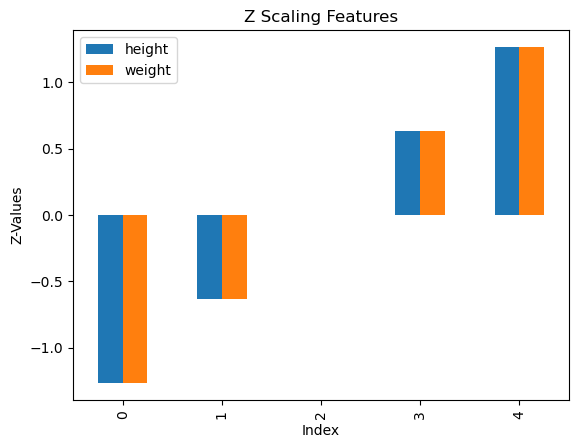

In [6]:
df1_z.plot(kind='bar')
plt.title("Z Scaling Features")
plt.xlabel('Index')
plt.ylabel('Z-Values')
plt.show()

---

# Min-Max Scaling (Normalization)

## মূল ধারণা

**Min-Max Scaling** হলো একটি **feature scaling** পদ্ধতি যেখানে যেকোনো numerical data-কে **[0, 1]** range-এ রূপান্তর করা হয়। এটি **Rescaling**-ও বলা হয়।

## Formula

$$x' = \frac{x - x_{min}}{x_{max} - x_{min}}$$

| Symbol | অর্থ |
|---|---|
| $x$ | মূল (original) মান |
| $x_{min}$ | dataset-এর সর্বনিম্ন মান |
| $x_{max}$ | dataset-এর সর্বোচ্চ মান |
| $x'$ | scaled মান (সবসময় 0 থেকে 1-এর মধ্যে) |

**লজিক:** মূল মান থেকে minimum বাদ দিয়ে, সেটাকে পুরো range (max − min) দিয়ে ভাগ করা হয়।

## উদাহরণ — Height ও Weight উভয়ই Scale করা

**Height:** $x_{min} = 150$, $x_{max} = 190$, range = $40$

**Weight:** $x_{min} = 50$, $x_{max} = 90$, range = $40$

| Person | Height (cm) | Scaled Height | Weight (Kg) | Scaled Weight |
|---|---|---|---|---|
| A | 150 | **(150−150)/40 = 0.00** | 50 | **(50−50)/40 = 0.00** |
| B | 160 | **(160−150)/40 = 0.25** | 60 | **(60−50)/40 = 0.25** |
| C | 170 | **(170−150)/40 = 0.50** | 70 | **(70−50)/40 = 0.50** |
| D | 180 | **(180−150)/40 = 0.75** | 80 | **(80−50)/40 = 0.75** |
| E | 190 | **(190−150)/40 = 1.00** | 90 | **(90−50)/40 = 1.00** |

> প্রতিটি feature আলাদাভাবে scale হয় — Height-এর জন্য Height-এর min/max, Weight-এর জন্য Weight-এর min/max ব্যবহার করা হয়।

## কেন দরকার?

- ML model-এ **Height (cm)** এবং **Weight (Kg)**-এর মতো ভিন্ন scale-এর features থাকলে model bias হয়ে যায়।
- Min-Max Scaling সব feature-কে **equal scale**-এ এনে দেয়, ফলে model সঠিকভাবে শিখতে পারে।
- **KNN**, **SVM**, **Neural Network**-এর মতো distance-based বা gradient-based algorithm-এ এটি বিশেষভাবে গুরুত্বপূর্ণ।

## সীমাবদ্ধতা

- **Outlier**-এর প্রতি sensitive — একটি অস্বাভাবিক বড়/ছোট মান পুরো scaling নষ্ট করে দিতে পারে।

In [7]:
df2 = pd.DataFrame(
    {
        # 'height': [150, 160, 170, 180, 190],
        # 'weight': [50, 60, 70, 80, 90]
        'height': [150, 175, 170, 180, 190],
        'weight': [50, 60, 70, 180, 90]
    }
)

df2

,height,weight
0,150,50
1,175,60
2,170,70
3,180,180
4,190,90


In [8]:
# Step-1: Min, Max, Range
df2_min = df2.min()
df2_max = df2.max()
df2_range = df2_max - df2_min
df2_min, df2_max, df2_range

(height    150
 weight     50
 dtype: int64,
 height    190
 weight    180
 dtype: int64,
 height     40
 weight    130
 dtype: int64)

In [9]:
# Step-2: Shift to zero
df2_shiftZero = df2 - df2_min
df2_shiftZero

,height,weight
0,0,0
1,25,10
2,20,20
3,30,130
4,40,40


In [10]:
# Step-3: Divide by range
df2_min_max = df2_shiftZero / df2_range
df2_min_max.round(2)

,height,weight
0,0.00,0.00
1,0.62,0.08
2,0.50,0.15
3,0.75,1.00
4,1.00,0.31


---

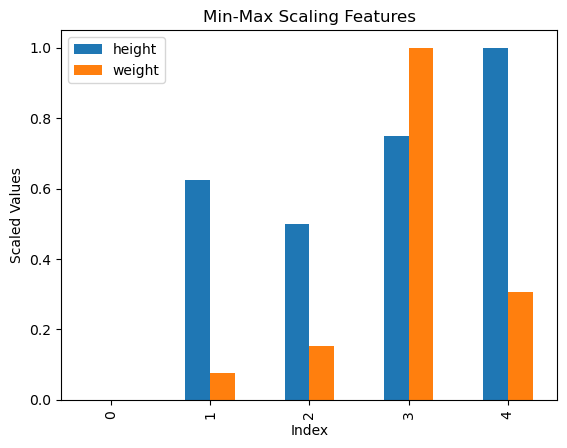

In [11]:
df2_min_max.plot(kind='bar')
plt.title("Min-Max Scaling Features")
plt.xlabel('Index')
plt.ylabel('Scaled Values')
plt.show()

# Robust Scaling (Outlier-Resistant)

## মূল ধারণা

**Robust Scaling** হলো এমন একটি **feature scaling** পদ্ধতি যেটি **outlier**-এর প্রভাব এড়িয়ে data scale করে। **Mean** বা **Min/Max**-এর বদলে এটি **median** এবং **IQR** ব্যবহার করে — কারণ এই দুটো **outlier**-এ প্রভাবিত হয় না।

## Formula

$$x' = \frac{x - \text{median}}{\text{IQR}}$$

যেখানে $\text{IQR} = Q3 - Q1$

| Symbol | অর্থ |
|---|---|
| $x$ | মূল (original) মান |
| $\text{median}$ | dataset-এর মধ্যমান |
| $\text{IQR}$ | Interquartile Range = Q3 − Q1 |
| $x'$ | scaled মান |

> **Min-Max Scaling**-এ E-এর মতো outlier (300, 200) পুরো scaling নষ্ট করে দেয়। **Robust Scaling** সেই সমস্যা এড়ায়।

## উদাহরণ — Height ও Weight উভয়ই Scale করা

লক্ষ্য করো, Person E-এর Height = **300** এবং Weight = **200** — এগুলো স্পষ্ট **outlier**।

### Height-এর হিসাব

Height values: 150, 160, 170, 180, 300

- $\text{median} = 170$
- $Q1 = 155$, $Q3 = 240$
- $\text{IQR} = 240 - 155 = 85$

### Weight-এর হিসাব

Weight values: 50, 60, 70, 80, 200

- $\text{median} = 70$
- $Q1 = 55$, $Q3 = 140$
- $\text{IQR} = 140 - 55 = 85$

### Scaled Table

| Person | Height (cm) | Scaled Height | Weight (Kg) | Scaled Weight |
|---|---|---|---|---|
| A | 150 | (150−170)/85 = **−0.24** | 50 | (50−70)/85 = **−0.24** |
| B | 160 | (160−170)/85 = **−0.12** | 60 | (60−70)/85 = **−0.12** |
| C | 170 | (170−170)/85 = **0.00** | 70 | (70−70)/85 = **0.00** |
| D | 180 | (180−170)/85 = **+0.12** | 80 | (80−70)/85 = **+0.12** |
| E | 300 | (300−170)/85 = **+1.53** | 200 | (200−70)/85 = **+1.53** |

> **Robust Scaling**-এ output **[0, 1]**-এ সীমাবদ্ধ থাকে না — outlier বড় মান পাবে, কিন্তু বাকি data-র scaling নষ্ট হবে না।

## Min-Max vs Robust — পার্থক্য

| বিষয় | Min-Max Scaling | Robust Scaling |
|---|---|---|
| ব্যবহার করে | min, max | median, IQR |
| Output range | সবসময় [0, 1] | fixed range নেই |
| Outlier-এ প্রভাব | হ্যাঁ, ক্ষতিগ্রস্ত হয় | না, প্রভাবিত হয় না |
| কখন ব্যবহার | outlier নেই এমন data-তে | outlier আছে এমন data-তে |

---

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df3 = pd.DataFrame({'h': [150, 160, 170, 180, 300],
                    'w': [50, 60, 70, 80, 200]})
df3

,h,w
0,150,50
1,160,60
2,170,70
3,180,80
4,300,200


In [13]:
# step 1: median, quartiles, IQR
df3_median = df3.median()
df3_q1 = df3.quantile(.25)
df3_q3 = df3.quantile(.75)
df3_iqr = df3_q3 - df3_q1
df3_median, df3_q1, df3_q3, df3_iqr

(h    170.0
 w     70.0
 dtype: float64,
 h    160.0
 w     60.0
 Name: 0.25, dtype: float64,
 h    180.0
 w     80.0
 Name: 0.75, dtype: float64,
 h    20.0
 w    20.0
 dtype: float64)

In [14]:
# step 2: center by median
df3_center = df3 - df3_median
df3_center

,h,w
0,-20.0,-20.0
1,-10.0,-10.0
2,0.0,0.0
3,10.0,10.0
4,130.0,130.0


In [15]:
# step 3: divide by IQR
df3_robust = df3_center/df3_iqr
df3_robust.round(2)

,h,w
0,-1.0,-1.0
1,-0.5,-0.5
2,0.0,0.0
3,0.5,0.5
4,6.5,6.5


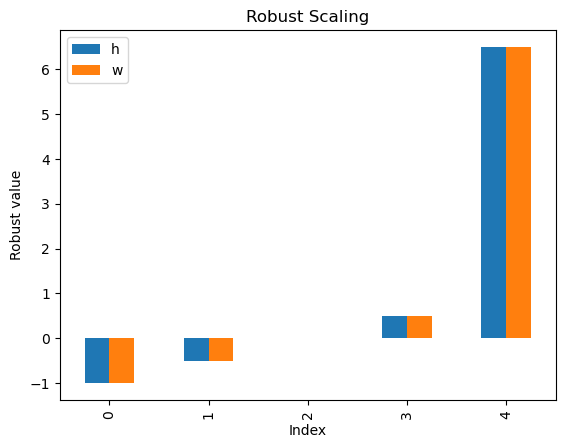

In [16]:
# visualize robust scaled values
df3_robust.plot(kind='bar')
plt.title("Robust Scaling")
plt.xlabel("Index");
plt.ylabel('Robust value')
plt.show()

---

In [17]:
comparison_of_scaling = pd.concat([df1, df1_z.add_prefix('z_'), df2_min_max.add_prefix('mm_'), df3_robust.add_prefix('rb_')], axis=1)
comparison_of_scaling.round(2)

,height,weight,z_height,z_weight,mm_height,mm_weight,rb_h,rb_w
0,150,50,-1.26,-1.26,0.00,0.00,-1.0,-1.0
1,160,60,-0.63,-0.63,0.62,0.08,-0.5,-0.5
2,170,70,0.00,0.00,0.50,0.15,0.0,0.0
3,180,80,0.63,0.63,0.75,1.00,0.5,0.5
4,190,90,1.26,1.26,1.00,0.31,6.5,6.5


---

## One-Hot Encoding

In [18]:
import pandas as pd

df4 = pd.DataFrame({
    "id": [1, 2, 3, 4],
    "color": ["red", "blue", "green", "red"],
    "size": ["Small", "Medium", "Large", "Medium"],
    "price": [10, 12, 15, 11]
})
df4

,id,color,size,price
0,1,red,Small,10
1,2,blue,Medium,12
2,3,green,Large,15
3,4,red,Medium,11


In [19]:
# Step 2: Apply one-hot encoding to the 'color' column
df4_color = pd.get_dummies(df4["color"], prefix="color", dtype = int)
df4_color

,color_blue,color_green,color_red
0,0,0,1
1,1,0,0
2,0,1,0
3,0,0,1


In [20]:
# Step 3: Combine the new columns back with the original data
df4_one_hot_encoded = pd.concat([df4, df4_color], axis=1)
df4_one_hot_encoded

,id,color,size,price,color_blue,color_green,color_red
0,1,red,Small,10,0,0,1
1,2,blue,Medium,12,1,0,0
2,3,green,Large,15,0,1,0
3,4,red,Medium,11,0,0,1


In [21]:
# Step 4: Drop the old 'color' column if you no longer need it
df4_one_hot_encoded = df4_one_hot_encoded.drop("color", axis=1)
print(df4_one_hot_encoded)

   id    size  price  color_blue  color_green  color_red
0   1   Small     10           0            0          1
1   2  Medium     12           1            0          0
2   3   Large     15           0            1          0
3   4  Medium     11           0            0          1


## Ordinal Encoding (for ordered categories)

In [22]:
import pandas as pd

df5 = pd.DataFrame({
    "id": [1, 2, 3, 4],
    "color": ["red", "blue", "green", "red"],
    "size": ["Small", "Medium", "Large", "Medium"],
    "price": [10, 12, 15, 11]
})
df5

,id,color,size,price
0,1,red,Small,10
1,2,blue,Medium,12
2,3,green,Large,15
3,4,red,Medium,11


In [23]:
# Step 2: declare the ordinal order
order = {"Small": 1, "Medium": 2, "Large": 3}

In [24]:
# Step 3: convert the whole feature
# df5["size_encoded"]=df5["size"].map(order).astype(int)
df5["size"] = df5["size"].map(order).astype(int)

In [25]:
df5

,id,color,size,price
0,1,red,1,10
1,2,blue,2,12
2,3,green,3,15
3,4,red,2,11


## Understanding Vectors, Dot Product, and Norms — A Hands-on Python Exploration

In [26]:
#Step 1: Creating Vectors
import numpy as np

# Two tiny 3D vectors
a = np.array([2, 1, 3])
b = np.array([1, 3, 3])

print(a)
print(b)

[2 1 3]
[1 3 3]


In [27]:
#Step 2: Vector Operations (Addition and Subtraction)
add_ab = a + b
sub_ab = a - b

print(add_ab)
print(sub_ab)

[3 4 6]
[ 1 -2  0]


In [28]:
#Step 3: Dot Product (Similarity of Direction)
# Manual dot product: sum of pairwise products. WeE'#ll do the same thing using 3 different syntaxes.
dot_1 = a[0] * b[0] + a[1] * b[1] + a[2] * b[2]
dot_2 = a @ b
dot_3 = np.dot(a, b)

print(dot_1)
print(dot_2)
print(dot_3)

14
14
14


In [29]:
#Step 4: Norms (Length or Magnitude of a Vector)
# L2 norm, the usual length

l2_a = np.linalg.norm(a)
print(l2_a)

l1_a = np.linalg.norm(a, ord=1)
print(l1_a)

3.7416573867739413
6.0


## Step 4: Norms (ভেক্টরের দৈর্ঘ্য বা মান)

সহজ কথায়, **Norm** মানে হলো একটি ভেক্টরের **দৈর্ঘ্য (Length)** বা **Magnitude**। মূলবিন্দু (0,0,0) থেকে ওই ভেক্টরটি কত দূরে অবস্থিত, সেটিই হলো তার Norm।

### ১. L2 Norm (Euclidean Norm)
এটি হলো আমাদের সাধারণ জ্যামিতিক দৈর্ঘ্য। আমরা স্কুলে পিথাগোরাসের সূত্রে যা শিখেছি, এটি ঠিক তাই।
একটি ভেক্টর $a = [x, y, z]$ হলে তার $L2$ Norm হবে:
$$\|a\|_2 = \sqrt{x^2 + y^2 + z^2}$$

**কোডে যা হচ্ছে:** `np.linalg.norm(a)`
আপনার ভেক্টর $a = [2, 1, 3]$ এর জন্য হিসেবটি হবে:
$$\sqrt{2^2 + 1^2 + 3^2} = \sqrt{4 + 1 + 9} = \sqrt{14} \approx 3.74$$

### ২. L1 Norm (Manhattan Norm)
L1 Norm দৈর্ঘ্যের হিসেবটা একটু ভিন্ন। এটি ডিরেক্ট দূরত্বের বদলে ভেক্টরের প্রতিটি মানের **পরম মান (Absolute value)** যোগ করে। একে "ট্যাক্সিক্যাব দূরত্ব"ও বলা হয়, কারণ এটি রাস্তার মোড় ঘোরার মতো করে দূরত্ব গুনে।
$$\|a\|_1 = |x| + |y| + |z|$$

**কোডে যা হচ্ছে:** `np.linalg.norm(a, ord=1)`
আপনার ভেক্টর $a = [2, 1, 3]$ এর জন্য:
$$|2| + |1| + |3| = 6$$


In [30]:
#Step 5: Normalizing a Vector (Unit Vector)
unit_a = a / np.linalg.norm(a)
len_unit_a = np.linalg.norm(unit_a)

print(unit_a)
print(len_unit_a)

[0.53452248 0.26726124 0.80178373]
1.0


## Step 5: Normalizing a Vector (Unit Vector)

**Normalization** বা নরমালইজ করার মানে হলো একটি বড় বা ছোট ভেক্টরকে এমনভাবে ছোট/বড় করা যাতে তার **দিক (Direction) ঠিক থাকে**, কিন্তু তার **দৈর্ঘ্য (Length) হয়ে যায় ঠিক ১**।

দৈর্ঘ্য ১ এমন ভেক্টরকে বলা হয় **Unit Vector**।

### এটি কেন করি?
মনে করো, দুইজন মানুষ একই দিকে দৌড়াচ্ছে, কিন্তু একজন জোরে আর একজন আস্তে। তাদের বেগ (Velocity) ভিন্ন হলেও দিক (Direction) একই। আমরা যখন শুধু দিকটা নিয়ে কাজ করতে চাই (যেমন: AI বা Machine Learning-এ ডেটা স্কেলিং করার সময়), তখন আমরা ভেক্টরটিকে নরমালইজ করে নিই।

### কোডে যা হচ্ছে:
```python
unit_a = a / np.linalg.norm(a)
```
১. প্রথমে আমরা ভেক্টর `a` এর আসল দৈর্ঘ্য বের করলাম (যেটা ছিল $\approx 3.74$)।
২. তারপর মূল ভেক্টর `a` এর প্রতিটি উপাদানকে ওই দৈর্ঘ্য দিয়ে ভাগ করে দিলাম।

**হিসেবটা অনেকটা এরকম:**
যদি একটা ৫ ইঞ্চি লম্বা লাঠি থাকে, আর সেটাকে যদি আমরা ৫ দিয়ে ভাগ করি, তবে আমরা ১ ইঞ্চি লম্বা একটি লাঠি পাব। কিন্তু লাঠিটা যেদিকে ছিল, সেদিকেই থাকবে।

### ফলাফল চেক করা:
```python
len_unit_a = np.linalg.norm(unit_a)
```
যেকোনো ভেক্টরকে নরমালইজ করার পর তার দৈর্ঘ্য মাপলে সবসময় **1.0** আসবে। এটিই প্রমাণ করে যে ভেক্টরটি এখন একটি **Unit Vector**।

### সারসংক্ষেপ:
* **Norm:** ভেক্টরটা কত বড় বা লম্বা (Length)।
* **L2 Norm:** সরাসরি দূরত্ব (Shortest path)।
* **L1 Norm:** সবগুলোর যোগফল (Absolute sum)।
* **Normalization:** ভেক্টরটিকে দিক ঠিক রেখে ১ দৈর্ঘ্যের বানিয়ে ফেলা।

---

## Euclidean and Manhattan Distance

In [31]:
import numpy as np

X = np.array([
    [70, 80],  # S1
    [60, 90],  # S2
    [85, 60],  # S3
    [78, 76],  # S4
    [62, 65],  # S5
], dtype=float)

q = np.array([75, 70], dtype=float)

print("X shape:", X.shape)
print("q:", q.tolist())

X shape: (5, 2)
q: [75.0, 70.0]


এই কোডটুকু আসলে ডাটা সায়েন্স বা মেশিন লার্নিংয়ের একটি প্রাথমিক ধাপ, যাকে বলা হয় **"Data Represention"**। এখানে তুমি তোমার তথ্যগুলোকে কম্পিউটার বা পাইথনের বোঝার উপযোগী করে সাজাচ্ছো।

## ১. ম্যাট্রিক্স $X$: আমাদের তথ্যভাণ্ডার
```python
X = np.array([
    [70, 80],  # S1 (Student 1)
    [60, 90],  # S2 (Student 2)
    [85, 60],  # S3 (Student 3)
    [78, 76],  # S4 (Student 4)
    [62, 65],  # S5 (Student 5)
], dtype=float)
```
এখানে $X$ হলো একটি **2D Array** বা **Matrix**। সহজভাবে বোঝার জন্য কল্পনা করো একটি এক্সেল শিট বা রেজাল্ট শিট।
* এখানে ৫টি সারি (Rows) আছে: $S1$ থেকে $S5$ পর্যন্ত। এগুলোকে আমরা বলতে পারি ৫ জন ছাত্রের তথ্য।
* প্রতিটি সারিতে ২টি করে কলাম (Columns) আছে। ধরো, প্রথম কলামটি হলো **গণিতের নম্বর** এবং দ্বিতীয়টি হলো **ইংরেজির নম্বর**।

## ২. ভেক্টর $q$: আমাদের প্রশ্ন বা কুয়েরি (Query)
```python
q = np.array([75, 70], dtype=float)
```
এখানে $q$ একটি **1D Array** বা **Vector**। ধরো, তোমার কাছে একজন নতুন ছাত্রের নম্বর আছে (গণিতে ৭৫, ইংরেজিতে ৭০) এবং তুমি দেখতে চাও তোমার ডাটাবেজে থাকা বাকি ৫ জনের মধ্যে কার সাথে এই নতুন ছাত্রের নম্বরের মিল বেশি।

এই $q$-কে বলা হয় **Query Vector**।

## ৩. Shape এবং Output বোঝা
```python
print("X shape:", X.shape)
```
`X.shape` কমান্ডটি তোমাকে বলে দেবে এই ম্যাট্রিক্সের গঠন কেমন। এটার আউটপুট আসবে `(5, 2)`।
* **5:** মানে এখানে ৫টি স্যাম্পল বা সারি আছে।
* **2:** মানে প্রতিটি স্যাম্পলের ২টি করে বৈশিষ্ট্য (Features) আছে।

## এটি বাস্তব জীবনে কোথায় কাজে লাগে? (Recommendation System)
ধরো, তুমি ইউটিউবে কোনো ভিডিও খুঁজছো।
* তোমার ডাটাবেজে থাকা হাজার হাজার ভিডিও হলো এই ম্যাট্রিক্স **$X$**।
* তুমি যে লিখে সার্চ করলে বা যে ভিডিওটি দেখলে, সেটি হলো তোমার কুয়েরি **$q$**।
* কম্পিউটার এখন এর আগে আমরা যে **Cosine Similarity** শিখেছি, সেটি ব্যবহার করে $q$ এর সাথে $X$ এর প্রতিটি সারির তুলনা করবে। যার সাথে $q$ এর মিল সবচেয়ে বেশি হবে, ইউটিউব সেই ভিডিওটিই তোমাকে সবার উপরে দেখাবে।


In [32]:
# Euclidean distances (L2)
eu = np.linalg.norm(X - q, axis=1)
print("Euclidean:", np.round(eu, 3).tolist())

Euclidean: [11.18, 25.0, 14.142, 6.708, 13.928]


এই এক লাইনের কোডটি আসলে ডাটা সায়েন্সের অন্যতম শক্তিশালী একটি কাজ করছে। এটি আমাদের কুয়েরি (Query) $q$ থেকে ডাটাবেজে থাকা প্রতিটি ছাত্রের ($X$ ম্যাট্রিক্সের প্রতিটি সারি) **সরাসরি দূরত্ব** মেপে বের করছে।

## ১. `X - q` করলে কী হয়? (Broadcasting)
এটি পাইথনের একটি জাদুকরী ক্ষমতা। $X$ হলো একটি ম্যাট্রিক্স ($5 \times 2$) আর $q$ হলো একটি ভেক্টর ($1 \times 2$)।
পাইথন এখানে $q$ কে $X$ এর প্রতিটি সারির সাথে বিয়োগ করে।

**ভেতরের হিসেবটা অনেকটা এরকম:**
* প্রথম ছাত্রের সাথে পার্থক্য: $[70-75, 80-70] = [-5, 10]$
* দ্বিতীয় ছাত্রের সাথে পার্থক্য: $[60-75, 90-70] = [-15, 20]$
... এভাবে ৫টি সারির জন্যই পার্থক্য বের হয়। একে বলে **Error বা Distance Vector**।

## ২. `np.linalg.norm(..., axis=1)` কেন?
আমরা জানি `norm` মানে দৈর্ঘ্য বা দূরত্ব। কিন্তু আমাদের কাছে এখন ৫টি আলাদা আলাদা পার্থক্যের ভেক্টর আছে।

* **`axis=1` এর কাজ:** এটি পাইথনকে বলে দেয়, "তুমি **পাশাপাশি (Horizontal)** হিসেব করো।" অর্থাৎ, প্রতিটা ছাত্রের জন্য আলাদা করে একটি একক দূরত্ব বের করো।
* এটি প্রতিটি ছাত্রের গণিত এবং ইংরেজির পার্থক্যের বর্গের যোগফলের রুট বের করে: $\sqrt{(\text{diff\_math})^2 + (\text{diff\_english})^2}$

## ৩. স্টেপ বাই স্টেপ ক্যালকুলেশন (S1 এর জন্য)
আমাদের $q = [75, 70]$ এবং প্রথম ছাত্র $S1 = [70, 80]$।
1.  **পার্থক্য:** $70-75 = -5$ এবং $80-70 = 10$
2.  **বর্গ (Square):** $(-5)^2 = 25$ এবং $10^2 = 100$
3.  **যোগফল:** $25 + 100 = 125$
4.  **রুট (Square Root):** $\sqrt{125} \approx 11.18$

এই $11.18$ সংখ্যাটিই বলে দিচ্ছে আমাদের কুয়েরি $q$ থেকে ছাত্র $S1$ কতটুকু দূরে আছে।

## ৪. আউটপুট বিশ্লেষণ
`print("Euclidean:", np.round(eu, 3).tolist())`
এই লাইনটি দূরত্বগুলোকে দশমিকের পর ৩ ঘর পর্যন্ত সুন্দর করে একটি লিস্ট আকারে দেখাবে।

**ফলাফল দেখে তুমি যা বুঝবে:**
* যে সংখ্যাটি **সবচেয়ে ছোট**, তার মানে সেই ছাত্রটি আমাদের কুয়েরি $q$ এর **সবচেয়ে কাছে (সবচেয়ে বেশি মিল)**।
* যে সংখ্যাটি **সবচেয়ে বড়**, সেই ছাত্রটি আমাদের কুয়েরি থেকে **সবচেয়ে দূরে (ভিন্ন রকম)**।

### বাস্তব উদাহরণ:
মনে করো এটি একটি **Recommendation System**। $q$ হলো তোমার পছন্দ। আর $X$ হলো ৫টি গান বা মুভি। ইউক্লিডিয়ান ডিস্টেন্স মেপে কম্পিউটার দেখবে কোন গানটির দূরত্ব তোমার পছন্দ থেকে সবচেয়ে কম, আর সেটিই তোমাকে সাজেস্ট করবে।

**সহজ মনে রাখার টিপস:**
* **`X - q`**: পার্থক্য বের করো।
* **`norm`**: দূরত্ব বের করো।
* **`axis=1`**: সারিবদ্ধভাবে (Row-wise) কাজ করো। এখন কি বুঝতে পারছো কেন `axis=1` না দিলে পুরো ম্যাট্রিক্সের একটি মাত্র রেজাল্ট আসতো? (কারণ তখন সে সবগুলোকে একটি বড় ভেক্টর মনে করতো)।

In [33]:
# Manhattan distances (L1)
ma = np.linalg.norm(X - q, ord=1, axis=1)
print("Manhattan:", ma.tolist())

Manhattan: [15.0, 35.0, 20.0, 9.0, 18.0]


ম্যানহাটন ডিস্টেন্স (Manhattan Distance) বা **L1 Norm** বের করার এই পদ্ধতিটি ইউক্লিডিয়ান ডিস্টেন্সের মতোই, কিন্তু এর হিসাব করার ধরনটা একটু ভিন্ন। এটি বুঝতে পারলে তুমি বুঝবে কেন এটাকে "ট্যাক্সিক্যাব দূরত্ব" বলা হয়।

## ১. ম্যানহাটন ডিস্টেন্স কী?
ইউক্লিডিয়ান ডিস্টেন্স হলো "পাখি ওড়ার মতো" সোজা দূরত্ব (Shortest Path)। আর ম্যানহাটন ডিস্টেন্স হলো "রাস্তা দিয়ে হাঁটার মতো" দূরত্ব। নিউ ইয়র্ক শহরের ম্যানহাটন এলাকায় রাস্তাগুলো গ্রিডের মতো সাজানো, তাই এক জায়গা থেকে অন্য জায়গায় যেতে হলে আপনাকে বিল্ডিংয়ের মাঝখান দিয়ে সোজা না গিয়ে ডানে-বামে বা উপরে-নিচে ঘুরে যেতে হয়।

## ২. কোডের প্রতিটি অংশ কী করছে?

```python
ma = np.linalg.norm(X - q, ord=1, axis=1)
```

* **`X - q`**: আগের মতোই, এটি আমাদের ডাটাবেজের ৫টি সারির (ছাত্রদের) সাথে আমাদের কুয়েরি $q$ এর পার্থক্যের ৫টি নতুন ভেক্টর দিচ্ছে।
* **`ord=1`**: এটিই আসল পরিবর্তন! এটি পাইথনকে বলে দেয় তুমি **L1 Norm** বের করো। এর মানে হলো পার্থক্যের সংখ্যাগুলোকে বর্গ (Square) না করে সরাসরি তাদের **পরম মান (Absolute Value)** বা শুধু ধনাত্মক মান যোগ করো।
* **`axis=1`**: এটি নিশ্চিত করে যে হিসাবটি প্রতিটি সারির (প্রতিটি ছাত্রের) জন্য আলাদা আলাদা ভাবে হচ্ছে।

## ৩. স্টেপ বাই স্টেপ ক্যালকুলেশন (S1 এর জন্য)
মনে করো, আমাদের কুয়েরি $q = [75, 70]$ এবং প্রথম ছাত্র $S1 = [70, 80]$।

1.  **পার্থক্য বের করা:** $70 - 75 = -5$ এবং $80 - 70 = 10$।
2.  **পরম মান (Absolute Value) নেওয়া:** $|-5| = 5$ এবং $|10| = 10$ (অর্থাৎ মাইনাস চিহ্ন থাকলেও সেটা প্লাস হয়ে যাবে)।
3.  **সরাসরি যোগ করা:** $5 + 10 = 15$।

ব্যাস! $S1$ এর জন্য ম্যানহাটন ডিস্টেন্স হলো **১৫**।

## ৪. ইউক্লিডিয়ান বনাম ম্যানহাটন (সহজ তুলনা)

| বিষয় | ইউক্লিডিয়ান (L2) | ম্যানহাটন (L1) |
| :--- | :--- | :--- |
| **সূত্র** | $\sqrt{a^2 + b^2}$ | $|a| + |b|$ |
| **ধরন** | সরাসরি শর্টকাট দূরত্ব। | গ্রিড বা রাস্তা বরাবর দূরত্ব। |
| **প্রভাব** | বড় পার্থক্যকে অনেক বেশি গুরুত্ব দেয় (যেহেতু বর্গ করা হয়)। | বড়-ছোট সব পার্থক্যকে সমানভাবে যোগ করে। |

## ৫. আউটপুট বিশ্লেষণ
`print("Manhattan:", ma.tolist())`
এটি প্রতিটি ছাত্রের জন্য বের করা যোগফলগুলো একটি লিস্ট আকারে দেখাবে।

**কেন এটি ব্যবহার করব?**
মেশিন লার্নিংয়ে যখন আমাদের কাছে এমন ডাটা থাকে যেখানে অনেক বেশি "Outliers" (খুবই অস্বাভাবিক বড় বা ছোট মান) থাকে, তখন ইউক্লিডিয়ান ডিস্টেন্স ব্যবহার করলে বর্গের কারণে হিসাব উল্টাপাল্টা হয়ে যেতে পারে। তখন ম্যানহাটন ডিস্টেন্স ব্যবহার করা বেশি নিরাপদ কারণ এটি অনেক বেশি "Stable"।

---